# Assignment 5: Perceptron

Data: `data.csv` — 100 samples, columns: `x1`, `x2`, `label` (0 or 1, no header)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('data.csv', header=None, names=['x1', 'x2', 'label'])
X = df[['x1', 'x2']].values
y = df['label'].values
df.head()

,x1,x2,label
0,0.78051,-0.063669,1
1,0.28774,0.291390,1
2,0.40714,0.178780,1
3,0.29230,0.421700,1
4,0.50922,0.352560,1


/var/folders/rd/0gc692sj3zjcy1df54_b4mfr0000gn/T/ipykernel_40035/1811940247.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


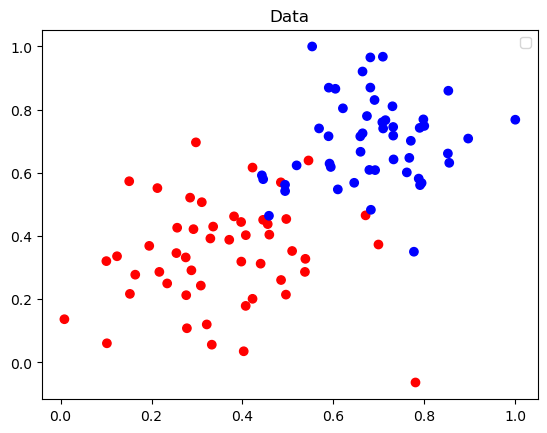

In [20]:
def plot_data(ax=None):
    if ax is None:
        _, ax = plt.subplots()
    mask = y == 1
    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
    return ax

ax = plot_data()
ax.set_title('Data')
ax.legend()
plt.show()

In [21]:
# Decision boundary: w1*x1 + w2*x2 + b = 0  =>  x2 = (-w1*x1 - b) / w2
def boundary_line(w, b, x_range=np.linspace(0, 1, 200)):
    w1, w2 = w
    return x_range, (-w1 * x_range - b) / w2

## Part 1 — Heuristic Perceptron (Binary / Step Function)


In [22]:
def perceptron_heuristic(X, y, learning_rate=0.1, n_iter=100, seed=42):
    np.random.seed(seed)
    w = np.random.randn(2)
    b = np.random.randn()
    history = [(w.copy(), b)]

    for _ in range(n_iter):
        for xi, yi in zip(X, y):
            z = w @ xi + b
            y_hat = 1 if z >= 0 else 0
            if y_hat != yi:
                if y_hat == 0:    
                    b += learning_rate
                    w += learning_rate * xi
                else:             
                    b -= learning_rate
                    w -= learning_rate * xi
        history.append((w.copy(), b))

    return history


def plot_heuristic(learning_rate=0.1, n_iter=100):
    history = perceptron_heuristic(X, y, learning_rate=learning_rate, n_iter=n_iter)
    x_vals = np.linspace(0, 1, 200)

    fig, ax = plt.subplots(figsize=(7, 6))
    plot_data(ax)

    # Initial — red
    xv, x2v = boundary_line(*history[0], x_vals)
    if xv is not None:
        ax.plot(xv, x2v, color='red', linewidth=1.5, label='Initial')

    # Intermediate — dashed green
    for state in history[1:-1]:
        xv, x2v = boundary_line(*state, x_vals)
        if xv is not None:
            ax.plot(xv, x2v, color='green', linestyle='--', linewidth=0.5, alpha=0.6)

    # Final — black
    xv, x2v = boundary_line(*history[-1], x_vals)
    if xv is not None:
        ax.plot(xv, x2v, color='black', linewidth=2, label='Final')

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f'Part 1 — Heuristic  |  lr={learning_rate}  |  iter={n_iter}')
    ax.legend()
    plt.tight_layout()
    plt.show()

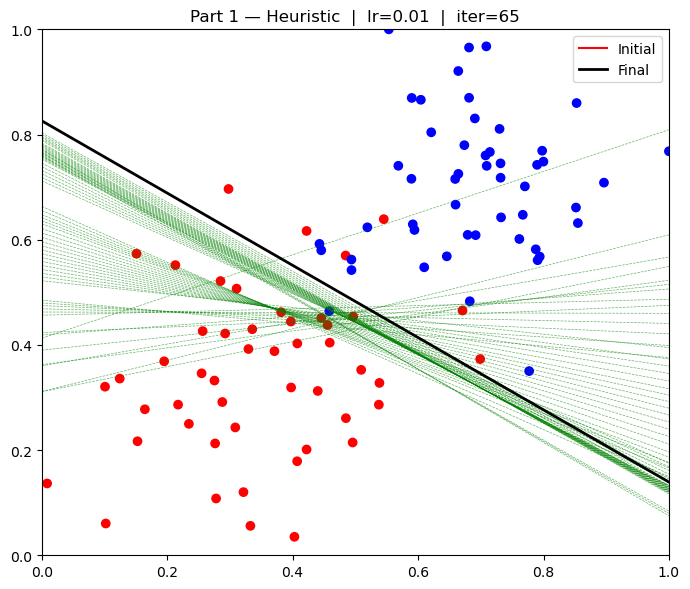

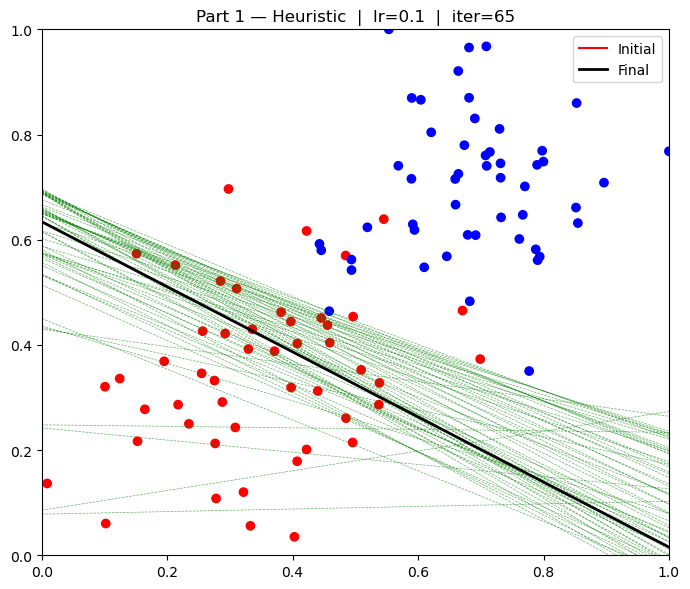

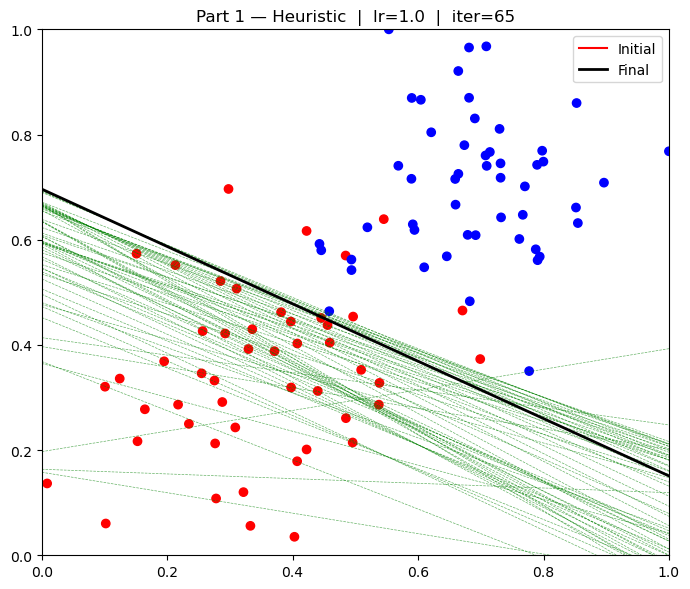

In [23]:
# Experiment: different learning rates (65 iterations each)
for lr in [0.01, 0.1, 1.0]:
    plot_heuristic(learning_rate=lr, n_iter=65)

## Part 2 — Gradient Descent Perceptron (Sigmoid)


In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(X, y, w, b):
    y_hat = sigmoid(X @ w + b)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def perceptron_gd(X, y, learning_rate=0.1, n_epochs=100, seed=42):
    np.random.seed(seed)
    w = np.random.randn(2)
    b = np.random.randn()
    history = [(w.copy(), b)]
    loss_history = []

    for epoch in range(n_epochs):
        for xi, yi in zip(X, y):
            y_hat = sigmoid(w @ xi + b)
            error = yi - y_hat
            b += learning_rate * error
            w += learning_rate * error * xi
        history.append((w.copy(), b))
        if (epoch + 1) % 10 == 0:
            loss_history.append((epoch + 1, log_loss(X, y, w, b)))

    return history, loss_history


def plot_gd(learning_rate=0.1, n_epochs=100):
    history, loss_history = perceptron_gd(X, y, learning_rate=learning_rate, n_epochs=n_epochs)
    x_vals = np.linspace(0, 1, 200)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    plot_data(ax1)

    # Initial — red
    xv, x2v = boundary_line(*history[0], x_vals)
    if xv is not None:
        ax1.plot(xv, x2v, color='red', linewidth=1.5, label='Initial')

    # Intermediate — dashed green
    for state in history[1:-1]:
        xv, x2v = boundary_line(*state, x_vals)
        if xv is not None:
            ax1.plot(xv, x2v, color='green', linestyle='--', linewidth=0.5, alpha=0.5)

    # Final — black
    xv, x2v = boundary_line(*history[-1], x_vals)
    if xv is not None:
        ax1.plot(xv, x2v, color='black', linewidth=2, label='Final')

    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
    ax1.set_title(f'Solution boundary  |  lr={learning_rate}  |  epochs={n_epochs}')
    ax1.legend()

    epochs_logged, losses = zip(*loss_history)
    ax2.plot(epochs_logged, losses)
    ax2.set_xlabel('Number of epochs')
    ax2.set_ylabel('Error')
    ax2.set_title('Error Plot')

    plt.tight_layout()
    plt.show()

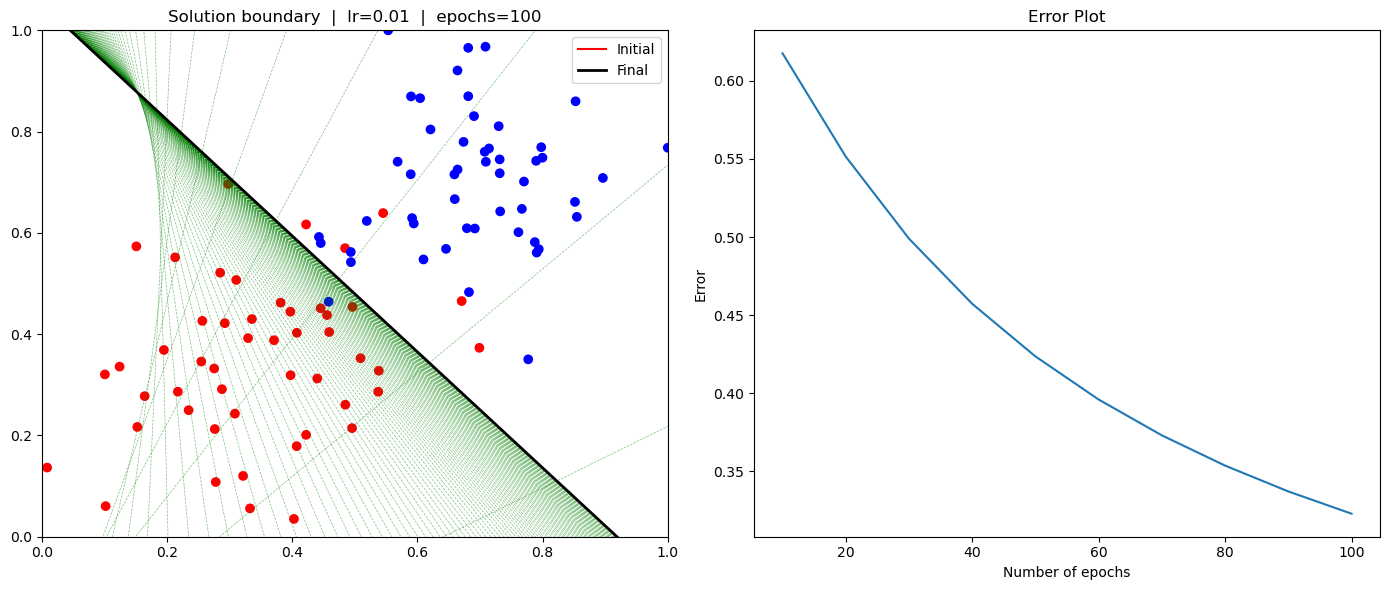

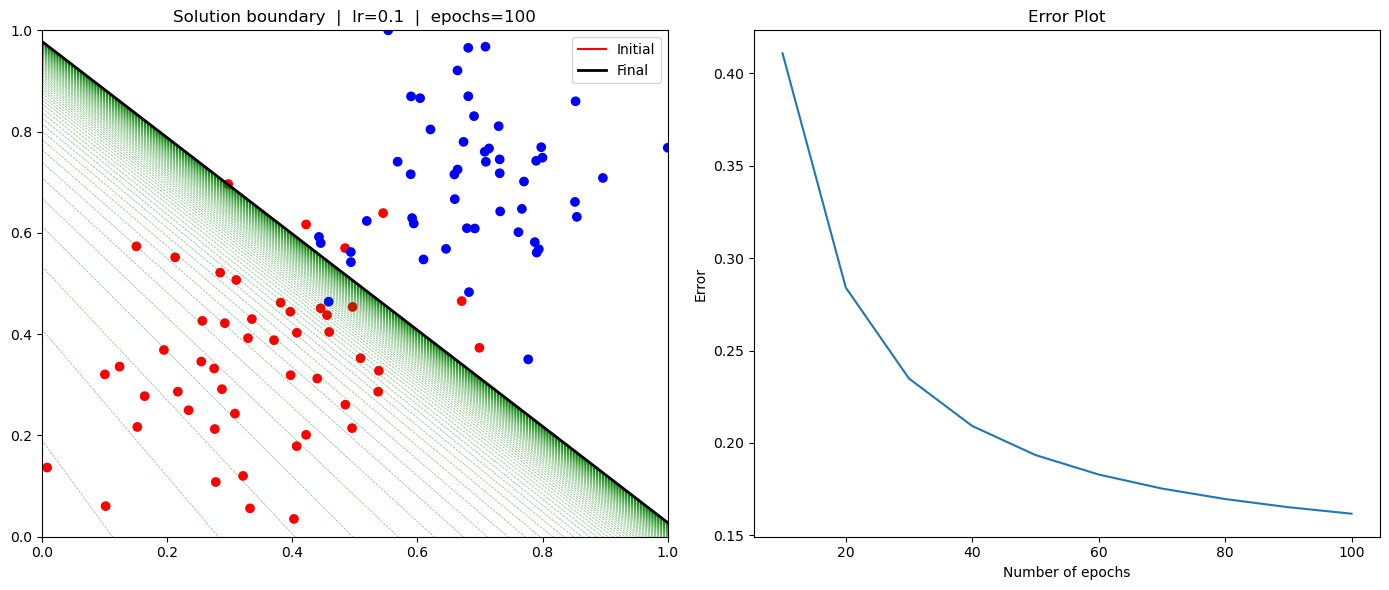

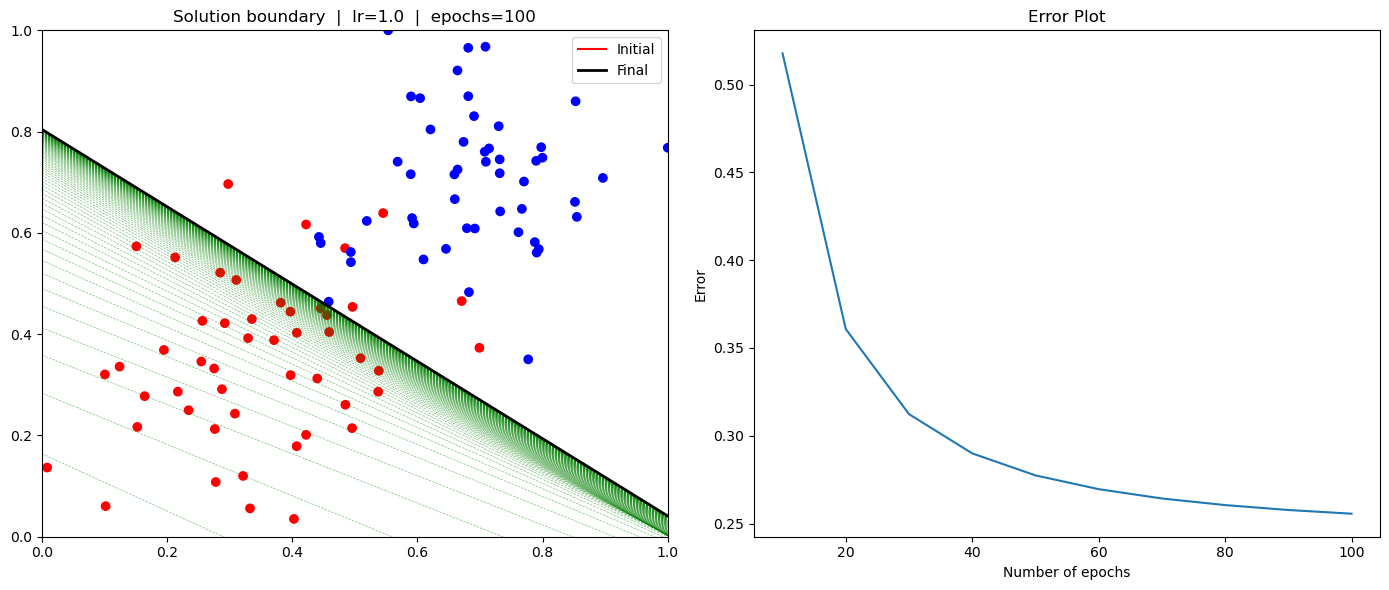

In [25]:
# Experiment: vary learning rate
for lr in [0.01, 0.1, 1.0]:
    plot_gd(learning_rate=lr, n_epochs=100)

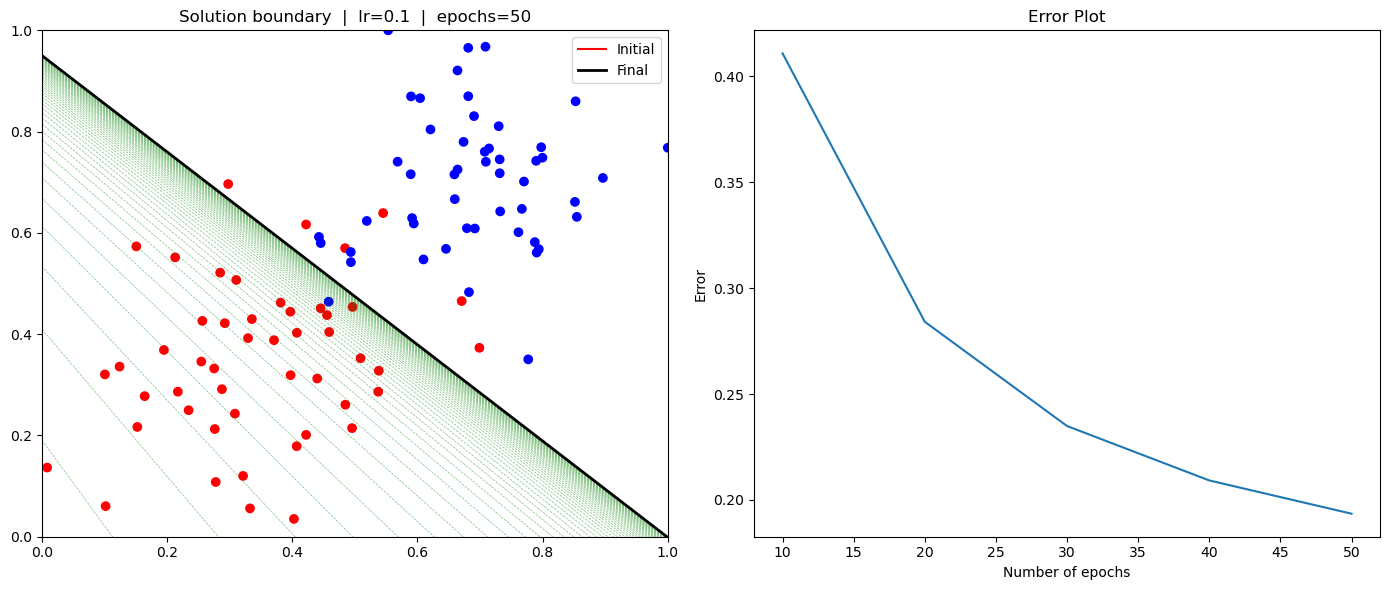

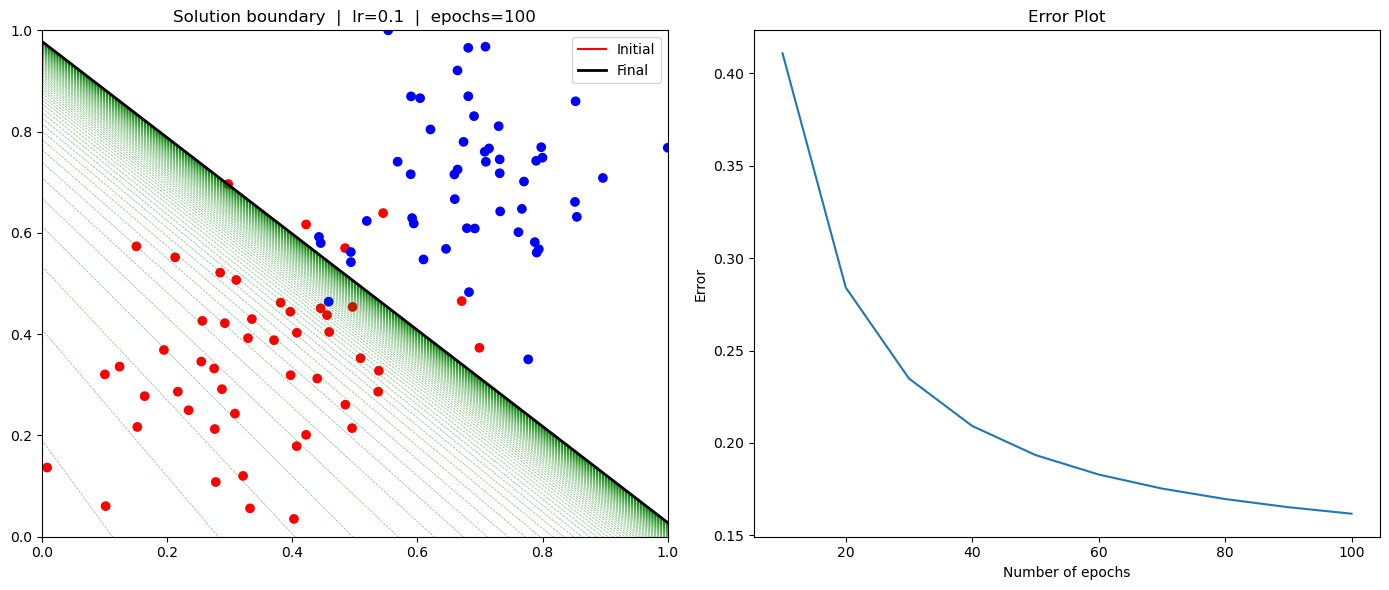

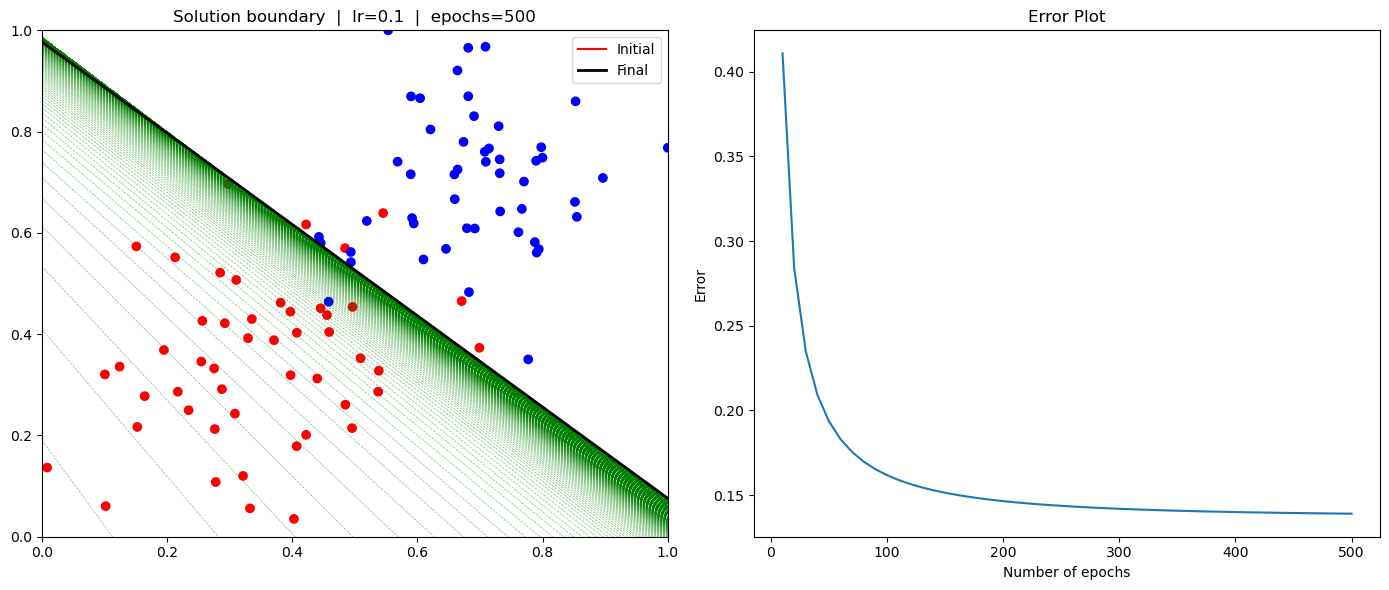

In [26]:
# Experiment: vary number of epochs
for ep in [50, 100, 500]:
    plot_gd(learning_rate=0.1, n_epochs=ep)